# Étude avancée des Residual Neural Networks

Ce notebook permet d'entrainer des modèles de 20 et 56 couches sur 30 epochs. Les modèles entrainés seront mis à disposition sur le git. Vous pourrez ensuite créer de nouveau modèles plus conséquents si vous le souhaitez en modifiant la valeur de n.

Après avoir codé ce premier ResNet à la main, nous nous rendons compte que chaque layer doit être ajouté à la main. Afin de faire des modèles plus conséquents, nous devons modifier la class ResNet pour qu'elle soit dynamique et prenne un paramètre n en input définissant la taille du modèle tel que

taille = 6 x n + 2

# Version avancée du ResNet

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

- Création de l'architeture du réseau PlainNet et ResNet

In [ ]:
class ResidualBlock(nn.Module):
	def __init__(self,in_channels,out_channels,stride=1):
		super().__init__() # on utilise les constructeurs de la classe mère

		self.conv1 = nn.Conv2d(
			in_channels= in_channels,
			out_channels=out_channels,
			kernel_size=3,
			stride=stride,
			padding=1,
			bias= False # le b de ax+b, ici ne sert à rien comme on fait un batch norm après, don cFalse pour éconimiser mémoire et calcul
		)
		self.bn1= nn.BatchNorm2d(out_channels) # recentrer les données (soustraire la moyenne)


		self.conv2 = nn.Conv2d(
				in_channels=out_channels,
				out_channels=out_channels,
				kernel_size=3,
				stride=1,
				padding=1,
				bias=False
			)
		self.bn2 = nn.BatchNorm2d(out_channels)

		# Maintenant on définit la shortcut connection
		self.shortcut = nn.Sequential() # conteneur

		# Si la taille de sortie est diff de celle d'entrée, on peut plus sommer x+F(x), donc on doit changer les dim
		if stride != 1 or in_channels != out_channels :
			self.shortcut = nn.Sequential(
				nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

	def forward(self, x):
		out = F.relu(self.bn1(self.conv1(x)))
		out = self.bn2(self.conv2(out))
		out += self.shortcut(x)
		out = F.relu(out)
		return out

In [ ]:
class ResNet(nn.Module):
	def __init__(self,n):
		super().__init__()
		self.in_channels = 16 # standard historique défini par le papier ResNet

		# Partie initiale
		self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
		self.bn1 = nn.BatchNorm2d(16)

		# Les 3 étages (Layers)
		# Layer 1 : 16 canaux, 2 blocs, stride 1 (on garde la taille 32x32)
		self.layer1 = self._make_layer(out_channels=16, num_blocks=n, stride=1)

		# Layer 2 : 32 canaux, 2 blocs, stride 2 (taille devient 16x16)
		self.layer2 = self._make_layer(out_channels=32, num_blocks=n, stride=2)

		# Layer 3 : 64 canaux, 2 blocs, stride 2 (taille devient 8x8)
		self.layer3 = self._make_layer(out_channels=64, num_blocks=n, stride=2)


		# Classifieur final
		self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # Moyenne globale 4x4 -> 1x1,

		self.fc = nn.Linear(64, 10) # 64 entrées -> 10 classes, calcule du score pour les 10 classes en fonction des 64 caractéristiques

	# fonction usine qui permet de définir un residual block
	def _make_layer(self, out_channels, num_blocks, stride):
		strides = [stride] + [1]*(num_blocks-1)
		layers = []
		for stride in strides:
			layers.append(ResidualBlock(self.in_channels, out_channels, stride))
			self.in_channels = out_channels
		return nn.Sequential(*layers)

	def forward(self, x):
		out = F.relu(self.bn1(self.conv1(x)))
		out = self.layer1(out)
		out = self.layer2(out)
		out = self.layer3(out)
		out = self.avgpool(out)
		out = torch.flatten(out, 1)
		out = self.fc(out) # calcule un score pour chacune des 10 classes parmi les 64 caractéristiques
		return out


In [ ]:
class PlainBlock(nn.Module):
	def __init__(self,in_channels,out_channels,stride=1):
		super().__init__() # on utilise les constructeurs de la classe mère

		self.conv1 = nn.Conv2d(
			in_channels= in_channels,
			out_channels=out_channels,
			kernel_size=3,
			stride=stride,
			padding=1,
			bias= False # le b de ax+b, ici ne sert à rien comme on fait un batch norm après, don cFalse pour éconimiser mémoire et calcul
		)
		self.bn1= nn.BatchNorm2d(out_channels) # recentrer les données (soustraire la moyenne)


		self.conv2 = nn.Conv2d(
				in_channels=out_channels,
				out_channels=out_channels,
				kernel_size=3,
				stride=1,
				padding=1,
				bias=False
			)
		self.bn2 = nn.BatchNorm2d(out_channels)

	def forward(self, x):
		out = F.relu(self.bn1(self.conv1(x)))
		out = self.bn2(self.conv2(out))
		out = F.relu(out)
		return out

In [ ]:
class PlainNet(nn.Module):
    def __init__(self,n):
        super().__init__()
        self.in_channels = 16 # standard historique défini par le papier ResNet

        # Partie initiale
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        # Les 3 étages (Layers)
        # Layer 1 : 16 canaux, 2 blocs, stride 1 (on garde la taille 32x32)
        self.layer1 = self._make_layer(out_channels=16, num_blocks=n, stride=1)

        # Layer 2 : 32 canaux, 2 blocs, stride 2 (taille devient 16x16)
        self.layer2 = self._make_layer(out_channels=32, num_blocks=n, stride=2)

        # Layer 3 : 64 canaux, 2 blocs, stride 2 (taille devient 8x8)
        self.layer3 = self._make_layer(out_channels=64, num_blocks=n, stride=2)


        # Classifieur final
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # Moyenne globale 4x4 -> 1x1,

        self.fc = nn.Linear(64, 10) # 64 entrées -> 10 classes, calcule du score pour les 10 classes en fonction des 64 caractéristiques

    # fonction usine qui permet de définir un residual block
    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(PlainBlock(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out) # calcule un score pour chacune des 10 classes parmi les 64 caractéristiques
        return out


- Import des données

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# On définit les transformations (Normalisation comme dans le papier)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Chargement de CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

# On vérifie si on a un GPU (vitesse ++)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

100%|██████████| 170M/170M [00:03<00:00, 47.1MB/s]


# Création du modèle 20 couches

In [ ]:
# Instanciation des modèles resnet20 et plainet20 pour n=3 : 6x3+2 couches
resnet20=ResNet(3)
plain20=PlainNet(3)

# Définition de la perte
criterion = nn.CrossEntropyLoss()

# Définition des optimiseurs (LR initial à 0.1 comme convenu)
optimizer_resnet = optim.SGD(resnet20.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0001)
optimizer_plain = optim.SGD(plain20.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0001)

Comparaison du nombre de paramètres

In [ ]:
total_resnet20 = sum(p.numel() for p in resnet20.parameters())
total_plain20 = sum(p.numel() for p in plain20.parameters())

print(f"Total paramètres ResNet-20 : {total_resnet20:,}")
print(f"Total paramètres Plain-20  : {total_plain20:,}")

Total paramètres ResNet-20 : 272,474
Total paramètres Plain-20  : 269,722


On voit bien ici que le nombre de paramètres entre les deux modèles est assez similaire. Avec une différence de seulement ~ 3000 paramètres, la différence n'est que de 1%. La différence du modèle ResNet est donc la structure centrale du réseau avec les shortcut connections.

- Entrainement du modèle 20 couches

In [ ]:
history = {
    'resnet_loss': [], 'resnet_acc': [],
    'plain_loss': [], 'plain_acc': []
}

epochs = 30 # Après 20 epochs, on essaie 30 pour avoir de meilleurs résultats

# Move models to the device
resnet20 = resnet20.to(device)
plain20 = plain20.to(device)

for epoch in range(epochs):
    resnet20.train()
    plain20.train()

    running_loss_resnet = 0.0
    running_loss_plain = 0.0

    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        # --- Entraînement du ResNet-20 ---
        optimizer_resnet.zero_grad()
        outputs_res = resnet20(inputs)
        loss_res = criterion(outputs_res, labels)
        loss_res.backward()
        optimizer_resnet.step()

        # --- Entraînement du Plain-20 ---
        optimizer_plain.zero_grad()
        outputs_plain = plain20(inputs)
        loss_plain = criterion(outputs_plain, labels)
        loss_plain.backward()
        optimizer_plain.step()

        # Statistiques
        running_loss_resnet += loss_res.item()
        running_loss_plain += loss_plain.item()

    # À la fin de chaque époque, on enregistre les moyennes
    history['resnet_loss'].append(running_loss_resnet / len(trainloader))
    history['plain_loss'].append(running_loss_plain / len(trainloader))

    print(f"Époque {epoch+1} terminée")

Époque 1 terminée
Époque 2 terminée
Époque 3 terminée
Époque 4 terminée
Époque 5 terminée
Époque 6 terminée
Époque 7 terminée
Époque 8 terminée
Époque 9 terminée
Époque 10 terminée
Époque 11 terminée
Époque 12 terminée
Époque 13 terminée
Époque 14 terminée
Époque 15 terminée
Époque 16 terminée
Époque 17 terminée
Époque 18 terminée
Époque 19 terminée
Époque 20 terminée
Époque 21 terminée
Époque 22 terminée
Époque 23 terminée
Époque 24 terminée
Époque 25 terminée
Époque 26 terminée
Époque 27 terminée
Époque 28 terminée
Époque 29 terminée
Époque 30 terminée


- Chargement des modèles ML depuis fichier existants (pas besoin de lancer si le modèle est entrainé)

In [ ]:
######## A LANCER QUE SI LE MODELE N'EST PAS ENTRAINÉ ########

import torch

# Instantiate the models
model_resnet = ResNet(3).to(device)
model_plain = PlainNet(3).to(device)

# Define the paths to the saved models
PATH_RESNET = './resnet20_cifar10.pth'
PATH_PLAIN = './plain20_cifar10.pth'

# Load the state dictionaries
model_resnet.load_state_dict(torch.load(PATH_RESNET))
model_plain.load_state_dict(torch.load(PATH_PLAIN))

print("Modèles ResNet-20 et Plain-20 chargés avec succès !")

Modèles ResNet-20 et Plain-20 chargés avec succès !


- Analyse du graphique

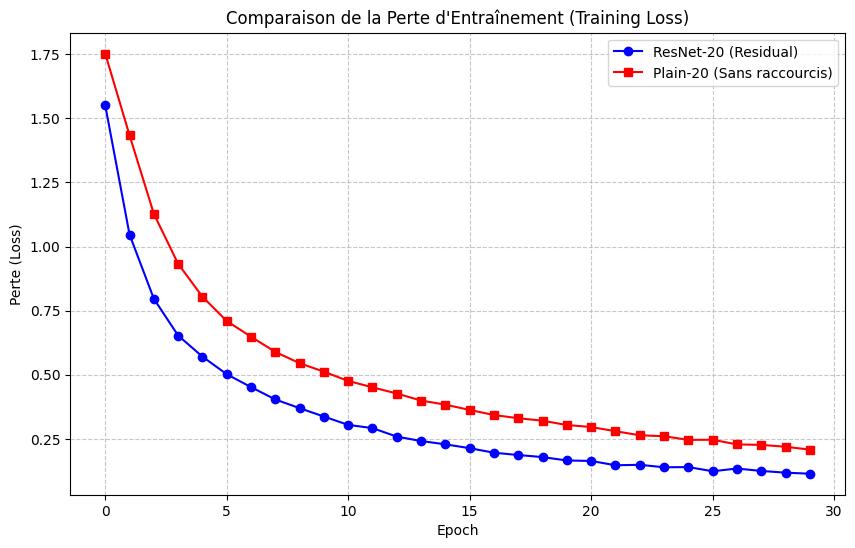

In [ ]:
import matplotlib.pyplot as plt

def plot_comparison(history):
    plt.figure(figsize=(10, 6))

    # Courbe pour le ResNet-20
    plt.plot(history['resnet_loss'], label='ResNet-20 (Residual)', color='blue', marker='o')

    # Courbe pour le Plain-20
    plt.plot(history['plain_loss'], label='Plain-20 (Sans raccourcis)', color='red', marker='s')

    plt.title('Comparaison de la Perte d\'Entraînement (Training Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Perte (Loss)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.show()

# Appel de la fonction avec tes données
plot_comparison(history)

- Sauvegarde du modèle

In [ ]:
# Sauvegarde des poids du ResNet

torch.save({
    'model_state_dict': resnet20.state_dict(),
    'epoch': epoch + 1,
    'training_loss': history['resnet_loss']
},
           'resnet20_cifar10.pth')

# Sauvegarde des poids du PlainNet
torch.save({
    'model_state_dict': plain20.state_dict(),
    'epoch': epoch + 1,
    'training_loss': history['plain_loss']
},
           'plain20_cifar10.pth')

print("Modèles sauvegardés avec succès ! ✅")

Modèles sauvegardés avec succès ! ✅


- Calcul des erreurs des modèles 20 couches

In [ ]:
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    error = 100 - accuracy
    return error

# Calcul des erreurs
error_res = evaluate_model(resnet20, testloader)
error_plain = evaluate_model(plain20, testloader)

print(f"Erreur Test ResNet-20 : {error_res:.2f}%")
print(f"Erreur Test Plain-20  : {error_plain:.2f}%")

Erreur Test ResNet-20 : 20.94%
Erreur Test Plain-20  : 23.93%


# Modèle à 56 couches

- Création des modèles 56 couches

In [ ]:
# Nouveau duel : n=9 pour 56 couches
model_resnet56 = ResNet(9).to(device)
model_plain56 = PlainNet(9).to(device)

# On garde le même LR initial
optimizer_res56 = optim.SGD(model_resnet56.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0001)
optimizer_plain56 = optim.SGD(model_plain56.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0001)

# Un "scheduler" pour réduire le LR automatiquement
scheduler_res = optim.lr_scheduler.MultiStepLR(optimizer_res56, milestones=[30, 45], gamma=0.1)
scheduler_plain = optim.lr_scheduler.MultiStepLR(optimizer_plain56, milestones=[30, 45], gamma=0.1)

- Entrainement du modèle

In [ ]:
history56 = {
    'resnet56_loss': [], 'resnet56_acc': [],
    'plain56_loss': [], 'plain56_acc': []
}

# --- Boucle d'entraînement CORRIGÉE ---
epochs = 30

for epoch in range(epochs):
    model_resnet56.train()
    model_plain56.train()

    running_loss_res56 = 0.0     #
    running_loss_plain56 = 0.0   #

    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        # --- Entraînement du ResNet-56 ---
        optimizer_res56.zero_grad()
        outputs_res = model_resnet56(inputs)
        loss_res = criterion(outputs_res, labels)
        loss_res.backward()
        optimizer_res56.step()

        # --- Entraînement du Plain-56 ---
        optimizer_plain56.zero_grad()
        outputs_plain = model_plain56(inputs)
        loss_plain = criterion(outputs_plain, labels)
        loss_plain.backward()
        optimizer_plain56.step()

        # Statistiques
        running_loss_res56 += loss_res.item()
        running_loss_plain56 += loss_plain.item()

    # Mise à jour du Learning Rate à la fin de l'époque
    scheduler_res.step()
    scheduler_plain.step()

    # Enregistrement
    history56['resnet56_loss'].append(running_loss_res56 / len(trainloader))
    history56['plain56_loss'].append(running_loss_plain56 / len(trainloader))

    print(f"Époque {epoch+1} terminée. LR: {scheduler_res.get_last_lr()[0]:.6f}")

Époque 1 terminée. LR: 0.100000
Époque 2 terminée. LR: 0.100000
Époque 3 terminée. LR: 0.100000
Époque 4 terminée. LR: 0.100000
Époque 5 terminée. LR: 0.100000
Époque 6 terminée. LR: 0.100000
Époque 7 terminée. LR: 0.010000
Époque 8 terminée. LR: 0.010000
Époque 9 terminée. LR: 0.010000
Époque 10 terminée. LR: 0.010000
Époque 11 terminée. LR: 0.010000
Époque 12 terminée. LR: 0.010000
Époque 13 terminée. LR: 0.010000
Époque 14 terminée. LR: 0.010000
Époque 15 terminée. LR: 0.010000
Époque 16 terminée. LR: 0.010000
Époque 17 terminée. LR: 0.010000
Époque 18 terminée. LR: 0.010000
Époque 19 terminée. LR: 0.010000
Époque 20 terminée. LR: 0.010000
Époque 21 terminée. LR: 0.010000
Époque 22 terminée. LR: 0.001000
Époque 23 terminée. LR: 0.001000
Époque 24 terminée. LR: 0.001000
Époque 25 terminée. LR: 0.001000
Époque 26 terminée. LR: 0.001000
Époque 27 terminée. LR: 0.001000
Époque 28 terminée. LR: 0.001000
Époque 29 terminée. LR: 0.001000
Époque 30 terminée. LR: 0.001000


- Sauvegarde du modèle

In [ ]:
# Sauvegarde des poids du ResNet
torch.save({
    'model_state_dict': model_resnet56.state_dict(),
    'epoch': epoch + 1,
    'training_loss': history56['resnet56_loss']
},
           'resnet56_cifar10.pth')

# Sauvegarde des poids du PlainNet
torch.save({
    'model_state_dict': model_plain56.state_dict(),
    'epoch': epoch + 1,
    'training_loss': history56['plain56_loss']
},
           'plain56_cifar10.pth')

print("Modèles sauvegardés avec succès ! ✅")

Modèles sauvegardés avec succès ! ✅


- Calcul des erreurs (changer en accuracy après)

In [ ]:
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    error = 100 - accuracy
    return error

# Calcul des erreurs
error_res56 = evaluate_model(model_resnet56, testloader)
error_plain56 = evaluate_model(model_plain56, testloader)

print(f"Erreur Test ResNet-56 : {error_res56:.2f}%")
print(f"Erreur Test Plain-56  : {error_plain56:.2f}%")

Erreur Test ResNet-56 : 17.13%
Erreur Test Plain-56  : 25.87%


- Analyse des graphiques d'entrainement

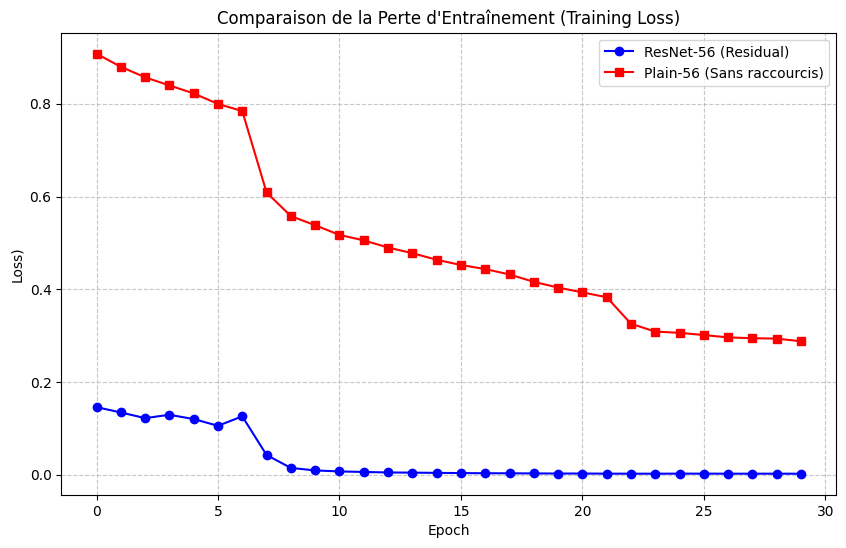

In [ ]:
import matplotlib.pyplot as plt

def plot_comparison(history):
    plt.figure(figsize=(10, 6))

    # Courbe pour le ResNet-20
    plt.plot(history['resnet56_loss'], label='ResNet-56 (Residual)', color='blue', marker='o')

    # Courbe pour le Plain-20
    plt.plot(history['plain56_loss'], label='Plain-56 (Sans raccourcis)', color='red', marker='s')

    plt.title('Comparaison de la Perte d\'Entraînement (Training Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.show()

# Appel de la fonction avec tes données
plot_comparison(history56)

# Comparaison des plots des modèles 20 et 56

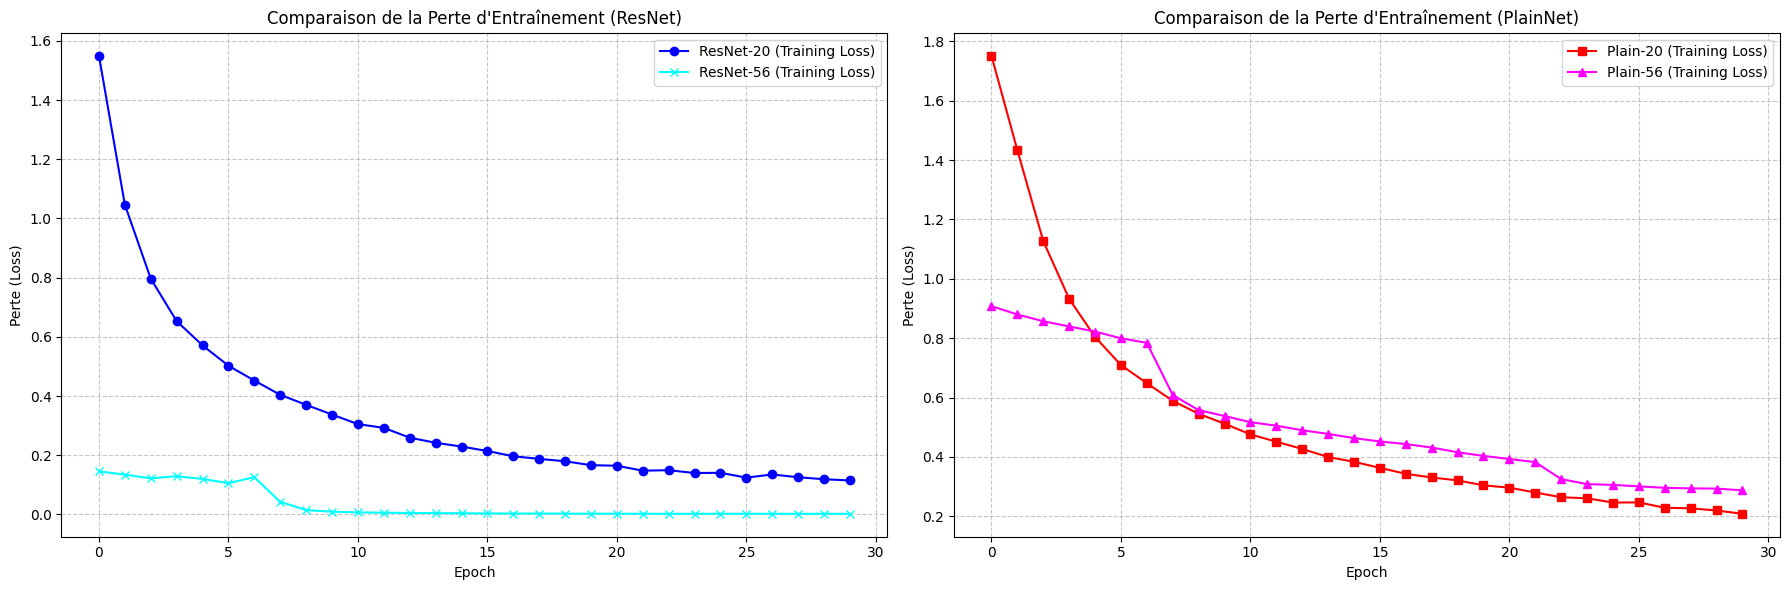

In [ ]:
import matplotlib.pyplot as plt

def plot_multiple_comparisons(history20, history56):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot for ResNet comparison
    ax1.plot(history20['resnet_loss'], label='ResNet-20 (Training Loss)', color='blue', marker='o')
    ax1.plot(history56['resnet56_loss'], label='ResNet-56 (Training Loss)', color='cyan', marker='x')
    ax1.set_title('Comparaison de la Perte d\'Entraînement (ResNet)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Perte (Loss)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Plot for PlainNet comparison
    ax2.plot(history20['plain_loss'], label='Plain-20 (Training Loss)', color='red', marker='s')
    ax2.plot(history56['plain56_loss'], label='Plain-56 (Training Loss)', color='magenta', marker='^')
    ax2.set_title('Comparaison de la Perte d\'Entraînement (PlainNet)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Perte (Loss)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Appel de la fonction avec les deux historiques
plot_multiple_comparisons(history, history56)

# A vous de jouer !

Maintenant vous pouvez soit entrainer un modèle de nouvelle taille en changeant le paramètre n pour avoir un modèle encore plus profond ou sinon utiliser les modèles déjà entrainés en les chargeant.

- Chargement du modèle et affichage

In [ ]:
# Check if device is available (from cell 5WgjA6s8sj27)
if 'device' not in locals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the ResNet model
model_loaded = ResNet(9).to(device)

# Define the path to the saved model
PATH_RESNET56 = 'resnet56_cifar10.pth' # vous pouvez choisir votre modèle

# Load the entire checkpoint (which includes model state dict, epoch, and training loss)
checkpoint = torch.load(PATH_RESNET56)

# Load the model's state dictionary
model_loaded.load_state_dict(checkpoint['model_state_dict'])

# Get the training loss from the checkpoint
training_loss_loaded = checkpoint['training_loss']

print("ResNet-56 model loaded successfully!")
print("Training Loss of loaded ResNet-56:")
for epoch_idx, loss_value in enumerate(training_loss_loaded):
    print(f"  Epoch {epoch_idx + 1}: {loss_value:.4f}")

ResNet-56 model loaded successfully!
Training Loss of loaded ResNet-56:
  Epoch 1: 0.1457
  Epoch 2: 0.1342
  Epoch 3: 0.1220
  Epoch 4: 0.1292
  Epoch 5: 0.1200
  Epoch 6: 0.1054
  Epoch 7: 0.1259
  Epoch 8: 0.0424
  Epoch 9: 0.0146
  Epoch 10: 0.0092
  Epoch 11: 0.0070
  Epoch 12: 0.0059
  Epoch 13: 0.0048
  Epoch 14: 0.0044
  Epoch 15: 0.0039
  Epoch 16: 0.0034
  Epoch 17: 0.0031
  Epoch 18: 0.0029
  Epoch 19: 0.0027
  Epoch 20: 0.0025
  Epoch 21: 0.0025
  Epoch 22: 0.0022
  Epoch 23: 0.0021
  Epoch 24: 0.0021
  Epoch 25: 0.0022
  Epoch 26: 0.0022
  Epoch 27: 0.0021
  Epoch 28: 0.0021
  Epoch 29: 0.0021
  Epoch 30: 0.0021


In [ ]:
import plotly.express as px
import pandas as pd

# Create a DataFrame for plotting
epochs = list(range(1, len(training_loss_loaded) + 1))
data_to_plot = pd.DataFrame({
    'Epoch': epochs,
    'Loss': training_loss_loaded
})

# Create the line plot using plotly.express
fig = px.line(data_to_plot, x='Epoch', y='Loss', title='Évolution de la Perte d\'Entraînement du ResNet-56')

# Customize the layout for better readability
fig.update_layout(
    xaxis_title='Époque',
    yaxis_title='Perte (Loss)',
    hovermode='x unified'
)

# Show the plot
fig.show()